<a href="https://colab.research.google.com/github/splakplutoy/tugas-sisdas-cv/blob/main/tugas_sisdas_cv_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Kelompok 3
1. Ferdiansyah Dwana Putra Santoso
2. Tazakka Ghefira Erza

# Tujuan Notebook Evaluasi

Notebook ini membandingkan performa dua pendekatan klasifikasi gambar casting: model CNN custom yang dibuat dengan kode dan model yang dibuat menggunakan Teachable Machine. Keduanya diuji pada dataset test yang sama agar hasil perbandingan lebih adil.

Evaluasi dilakukan dengan confusion matrix, classification report, ROC AUC, dan visualisasi contoh prediksi yang salah. Bagian prediksi salah digunakan untuk memenuhi analisis error: jika model keliru, penyebabnya perlu dijelaskan berdasarkan karakter gambar, preprocessing, dan karakteristik model.


## Memuat Model

Cell ini memuat dua model yang akan dibandingkan. Model custom dimuat dari file hasil training, sedangkan model Teachable Machine dimuat dari file `keras_model.h5` dan labelnya dari `labels.txt`.

Ukuran input kedua model berbeda. Model custom menggunakan gambar grayscale 300 x 300, sementara Teachable Machine umumnya menggunakan gambar RGB 224 x 224. Perbedaan ukuran dan format input ini harus diperhatikan agar hasil evaluasi tidak salah akibat preprocessing yang tidak sesuai.


In [ ]:
import os
from pathlib import Path

# Tetap gunakan Keras versi 2 (Legacy) agar model Teachable Machine aman di Colab.
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import kagglehub
import numpy as np
import tensorflow as tf
from google.colab import drive
from tensorflow.keras.layers import BatchNormalization, Conv2D, Dense, Dropout, GlobalAveragePooling2D, Input, MaxPooling2D
from tensorflow.keras.models import Sequential

drive.mount('/content/drive')

SEED = 42
CUSTOM_IMG_SIZE = (300, 300)
TM_IMG_SIZE = (224, 224)
BATCH_SIZE = 32

np.random.seed(SEED)
tf.random.set_seed(SEED)

custom_weights_path = Path('/content/drive/MyDrive/Model Tugas CNN/Model Custom/best_model_kustom_qc.weights.h5')
custom_model_path = Path('/content/drive/MyDrive/Model Tugas CNN/Model Custom/model_kustom_qc.keras')
legacy_custom_model_path = Path('/content/drive/MyDrive/Model Tugas CNN/Model Custom/model_kustom_qc.h5')
tm_model_path = Path('/content/drive/MyDrive/Model Tugas CNN/Model Teachable Machine/keras_model.h5')
tm_labels_path = Path('/content/drive/MyDrive/Model Tugas CNN/Model Teachable Machine/labels.txt')
alternate_tm_labels_paths = [
    Path('/content/drive/MyDrive/Model Tugas CNN/converted_keras/labels.txt'),
    Path('/content/labels.txt'),
    Path('labels.txt')
]

print("\nMemuat Model Teachable Machine...")
model_tm = tf.keras.models.load_model(tm_model_path, compile=False)

def build_improved_custom_model():
    return Sequential([
        Input(shape=(CUSTOM_IMG_SIZE[0], CUSTOM_IMG_SIZE[1], 1)),
        Conv2D(32, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Conv2D(256, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])


def build_legacy_custom_model():
    return Sequential([
        Input(shape=(CUSTOM_IMG_SIZE[0], CUSTOM_IMG_SIZE[1], 1)),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(256, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        tf.keras.layers.Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])


print("Memuat Model Custom...")
if custom_weights_path.exists():
    model_kustom = build_improved_custom_model()
    model_kustom.load_weights(custom_weights_path)
elif custom_model_path.exists():
    model_kustom = tf.keras.models.load_model(custom_model_path)
elif legacy_custom_model_path.exists():
    model_kustom = build_legacy_custom_model()
    model_kustom.load_weights(legacy_custom_model_path)
else:
    raise FileNotFoundError(
        f"Model custom tidak ditemukan. Cek {custom_weights_path}, {custom_model_path}, atau {legacy_custom_model_path}"
    )

print("Kedua model berhasil dimuat.")

print("\nMengunduh dataset untuk evaluasi...")
dataset_path = Path(kagglehub.dataset_download("ravirajsinh45/real-life-industrial-dataset-of-casting-product"))

base_dir = dataset_path / 'casting_data' / 'casting_data'
if not base_dir.exists():
    base_dir = dataset_path / 'casting_data'

test_dir = base_dir / 'test'
print(f"Folder data testing siap di: {test_dir}")





Mounted at /content/drive

Memuat Model Teachable Machine...
Memuat Model Custom...
Kedua model berhasil dimuat.

Mengunduh dataset untuk evaluasi...
Using Colab cache for faster access to the 'real-life-industrial-dataset-of-casting-product' dataset.
Folder data testing siap di: /kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test


## Menyiapkan Data Test

Dataset test dipakai sebagai data ujian akhir karena tidak digunakan pada proses training model custom. Untuk model custom, gambar diubah menjadi grayscale dan dinormalisasi ke rentang 0-1. Untuk Teachable Machine, gambar tetap RGB dan dinormalisasi ke rentang -1 sampai 1 sesuai format input model Teachable Machine.

Kedua generator dibuat dengan `shuffle=False` supaya urutan gambar sama. Ini penting karena prediksi model harus dibandingkan dengan label asli pada indeks gambar yang sama.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen_kustom = ImageDataGenerator(rescale=1./255)

print("Menyiapkan Data Ujian untuk Model Custom...")
test_generator_kustom = test_datagen_kustom.flow_from_directory(
    test_dir,
    target_size=CUSTOM_IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

def tm_preprocessing(img):
    return (img / 127.5) - 1.0

test_datagen_tm = ImageDataGenerator(preprocessing_function=tm_preprocessing)

print("\nMenyiapkan Data Ujian untuk Teachable Machine...")
test_generator_tm = test_datagen_tm.flow_from_directory(
    test_dir,
    target_size=TM_IMG_SIZE,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\nKunci Jawaban Kelas Custom:", test_generator_kustom.class_indices)
print("Kunci Jawaban Kelas TM    :", test_generator_tm.class_indices)

class_indices = test_generator_kustom.class_indices
display_names = {
    class_indices['def_front']: 'Defective (Cacat)',
    class_indices['ok_front']: 'OK (Bagus)'
}
class_names = [display_names[i] for i in range(len(display_names))]





Menyiapkan Data Ujian untuk Model Custom...
Found 715 images belonging to 2 classes.

Menyiapkan Data Ujian untuk Teachable Machine...
Found 715 images belonging to 2 classes.

Kunci Jawaban Kelas Custom: {'def_front': 0, 'ok_front': 1}
Kunci Jawaban Kelas TM    : {'def_front': 0, 'ok_front': 1}


## Metrik Evaluasi

Confusion matrix menunjukkan jumlah prediksi benar dan salah untuk setiap kelas. Dari matrix ini dapat dilihat dua jenis error penting: barang cacat diprediksi OK, dan barang OK diprediksi cacat. Dalam konteks quality control, error paling berbahaya adalah barang cacat diprediksi OK karena produk rusak dapat lolos inspeksi.

Classification report menampilkan precision, recall, dan F1-score. Precision menunjukkan seberapa tepat prediksi suatu kelas, recall menunjukkan seberapa banyak data pada kelas tersebut berhasil ditemukan, dan F1-score merangkum precision dan recall. ROC AUC digunakan untuk melihat kemampuan model membedakan dua kelas pada berbagai threshold.


Mapping label TM dari: /content/drive/MyDrive/Model Tugas CNN/Model Teachable Machine/labels.txt
Mapping output TM -> label generator: {0: 1, 1: 0}

Model Custom sedang mengerjakan ujian...
23/23 [==============================] - 62s 3s/step

Model Teachable Machine sedang mengerjakan ujian...
23/23 [==============================] - 14s 567ms/step



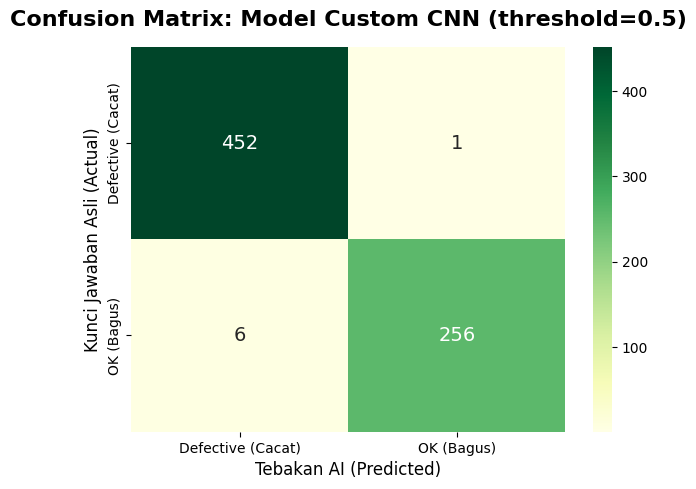


Rapor Detail Confusion Matrix: Model Custom CNN (threshold=0.5):
                   precision    recall  f1-score   support

Defective (Cacat)       0.99      1.00      0.99       453
       OK (Bagus)       1.00      0.98      0.99       262

         accuracy                           0.99       715
        macro avg       0.99      0.99      0.99       715
     weighted avg       0.99      0.99      0.99       715




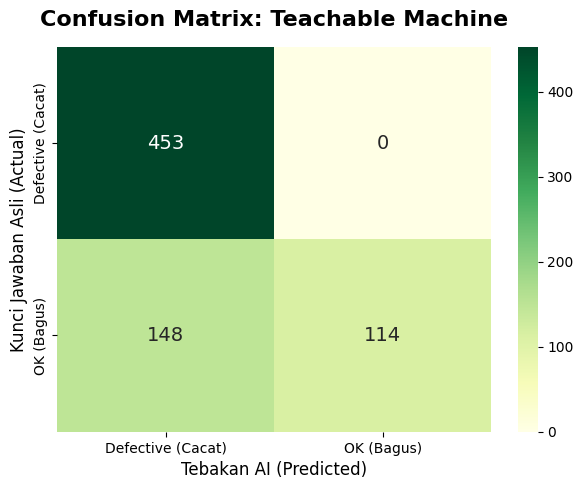


Rapor Detail Confusion Matrix: Teachable Machine:
                   precision    recall  f1-score   support

Defective (Cacat)       0.75      1.00      0.86       453
       OK (Bagus)       1.00      0.44      0.61       262

         accuracy                           0.79       715
        macro avg       0.88      0.72      0.73       715
     weighted avg       0.84      0.79      0.77       715


ROC AUC Model Custom CNN: 0.9999
ROC AUC Teachable Machine: 0.9601

Analisis threshold Model Custom:
Threshold | Accuracy | Recall Defect | False Negative Defect
     0.30 |   0.9958 |        0.9956 |                     2
     0.50 |   0.9902 |        0.9978 |                     1
     0.70 |   0.9874 |        1.0000 |                     0
     0.90 |   0.9776 |        1.0000 |                     0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def load_tm_label_mapping(*candidate_paths):
    for path in candidate_paths:
        if path.exists():
            mapping = {}
            for raw_line in path.read_text(encoding='utf-8').splitlines():
                raw_line = raw_line.strip()
                if not raw_line:
                    continue
                index_text, label = raw_line.split(maxsplit=1)
                normalized = label.lower()
                if 'bagus' in normalized or 'ok' in normalized:
                    mapping[int(index_text)] = class_indices['ok_front']
                elif 'cacat' in normalized or 'def' in normalized:
                    mapping[int(index_text)] = class_indices['def_front']
                else:
                    raise ValueError(f"Label Teachable Machine tidak dikenali: {label}")
            return mapping, path
    raise FileNotFoundError("labels.txt Teachable Machine tidak ditemukan.")

tm_to_generator_label, used_labels_path = load_tm_label_mapping(tm_labels_path, *alternate_tm_labels_paths)
print("Mapping label TM dari:", used_labels_path)
print("Mapping output TM -> label generator:", tm_to_generator_label)

y_true = test_generator_kustom.classes

print("\nModel Custom sedang mengerjakan ujian...")
pred_prob_kustom = model_kustom.predict(test_generator_kustom).reshape(-1)

print("\nModel Teachable Machine sedang mengerjakan ujian...")
pred_prob_tm = model_tm.predict(test_generator_tm)
y_pred_tm_raw = np.argmax(pred_prob_tm, axis=1)
y_pred_tm = np.array([tm_to_generator_label[idx] for idx in y_pred_tm_raw])

DEFAULT_THRESHOLD = 0.5
y_pred_kustom = (pred_prob_kustom > DEFAULT_THRESHOLD).astype(int)

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='YlGn',
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={"size": 14}
    )

    plt.title(title, fontname='sans-serif', fontsize=16, pad=15, fontweight='bold')
    plt.ylabel('Kunci Jawaban Asli (Actual)', fontname='sans-serif', fontsize=12)
    plt.xlabel('Tebakan AI (Predicted)', fontname='sans-serif', fontsize=12)
    plt.xticks(fontname='sans-serif')
    plt.yticks(fontname='sans-serif')
    plt.show()

    print(f"\nRapor Detail {title}:")
    print(classification_report(y_true, y_pred, target_names=class_names))

print("\n" + "="*60)
plot_cm(y_true, y_pred_kustom, f"Confusion Matrix: Model Custom CNN (threshold={DEFAULT_THRESHOLD})")

print("\n" + "="*60)
plot_cm(y_true, y_pred_tm, "Confusion Matrix: Teachable Machine")

custom_auc = roc_auc_score(y_true, pred_prob_kustom)
print(f"\nROC AUC Model Custom CNN: {custom_auc:.4f}")

if pred_prob_tm.shape[1] == 2:
    ok_tm_index = next(tm_idx for tm_idx, gen_idx in tm_to_generator_label.items() if gen_idx == class_indices['ok_front'])
    tm_auc = roc_auc_score(y_true, pred_prob_tm[:, ok_tm_index])
    print(f"ROC AUC Teachable Machine: {tm_auc:.4f}")

print("\nAnalisis threshold Model Custom:")
print("Threshold | Accuracy | Recall Defect | False Negative Defect")
for threshold in [0.3, 0.5, 0.7, 0.9]:
    y_pred_threshold = (pred_prob_kustom > threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred_threshold, labels=[class_indices['def_front'], class_indices['ok_front']])
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tn + tp) / cm.sum()
    recall_defect = tn / (tn + fp) if (tn + fp) else 0
    false_negative_defect = fp
    print(f"{threshold:9.2f} | {accuracy:8.4f} | {recall_defect:13.4f} | {false_negative_defect:21d}")





Custom CNN: Defective Diprediksi OK: menampilkan 1 dari 1 gambar


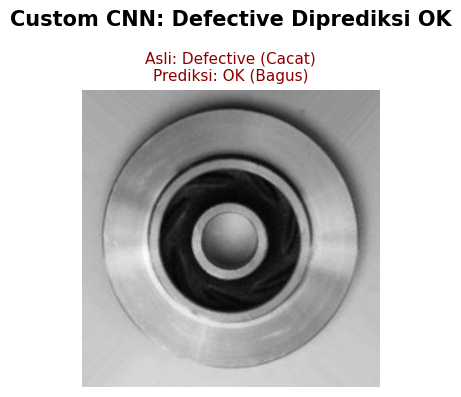

Custom CNN: OK Diprediksi Defective: menampilkan 6 dari 6 gambar


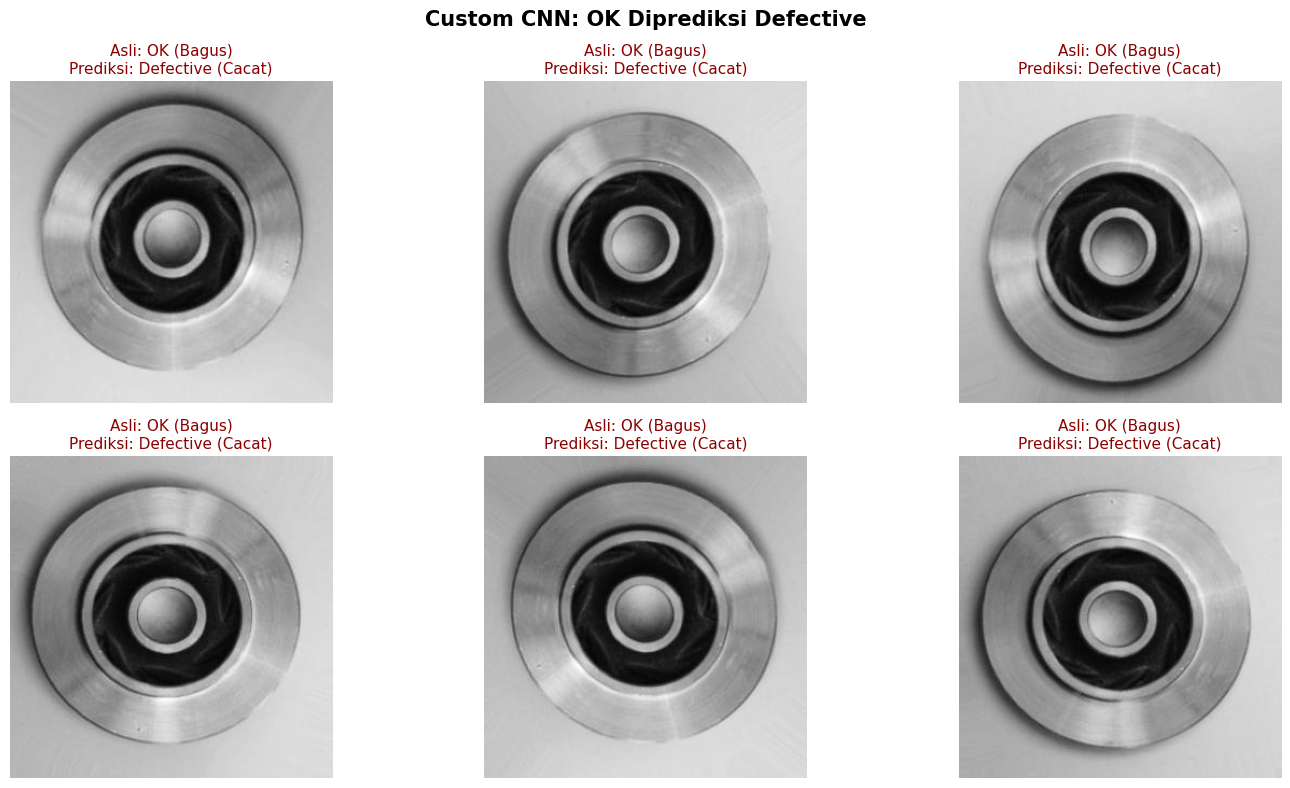

Teachable Machine: Defective Diprediksi OK: menampilkan 0 dari 0 gambar
Tidak ada sampel untuk kategori ini.
Teachable Machine: OK Diprediksi Defective: menampilkan 6 dari 148 gambar


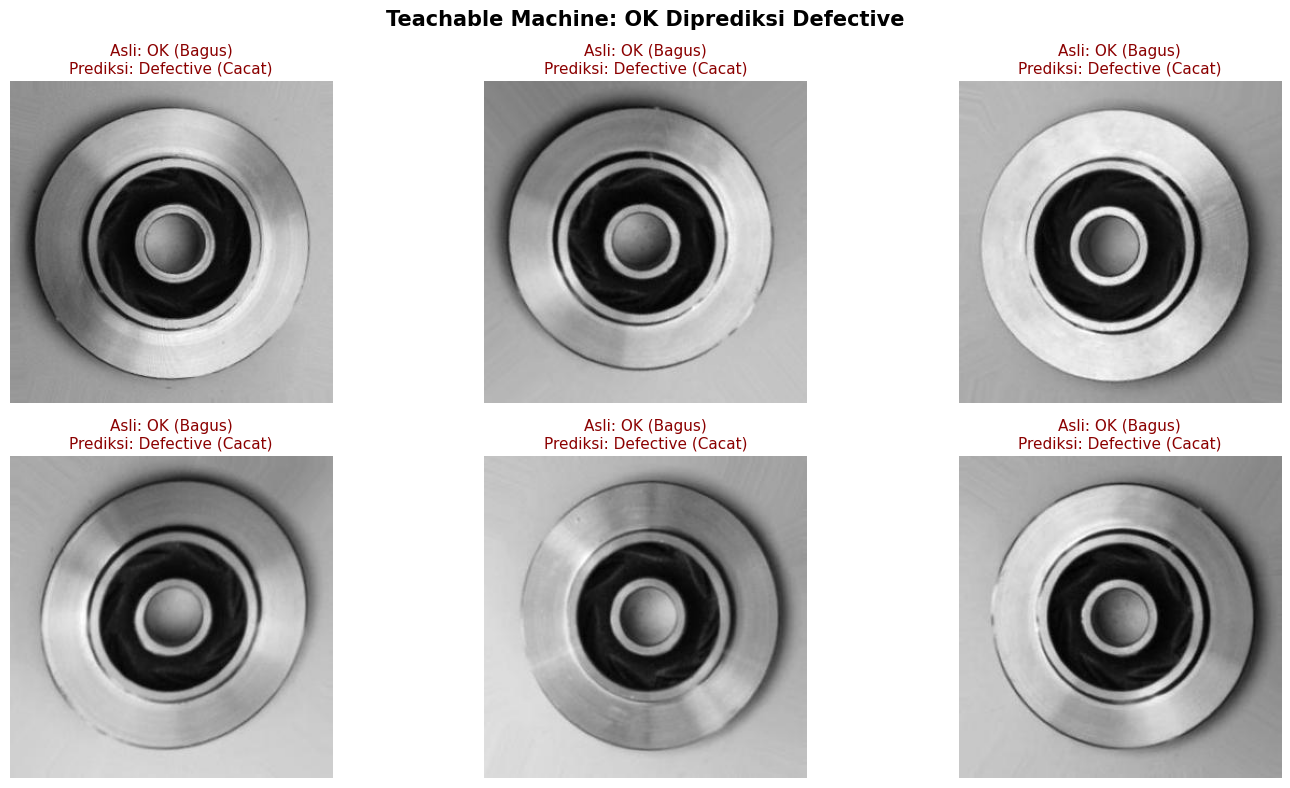

In [ ]:
import matplotlib.image as mpimg

def show_error_samples(indices, generator, y_pred, title, max_images=6, cmap=None):
    total = len(indices)
    print(f"{title}: menampilkan {min(total, max_images)} dari {total} gambar")

    if total == 0:
        print("Tidak ada sampel untuk kategori ini.")
        return

    sample_indices = indices[:max_images]
    cols = min(3, len(sample_indices))
    rows = int(np.ceil(len(sample_indices) / cols))

    plt.figure(figsize=(5 * cols, 4 * rows))
    for i, idx in enumerate(sample_indices):
        plt.subplot(rows, cols, i + 1)
        img_path = generator.filepaths[idx]
        img = mpimg.imread(img_path)
        plt.imshow(img, cmap=cmap)

        actual = display_names[y_true[idx]]
        predicted = display_names[y_pred[idx]]
        plt.title(f"Asli: {actual}\nPrediksi: {predicted}", color='darkred', fontsize=11)
        plt.axis('off')

    plt.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Dalam quality control, kasus paling berbahaya adalah defective diprediksi OK.
defect_as_ok_kustom = np.where((y_true == class_indices['def_front']) & (y_pred_kustom == class_indices['ok_front']))[0]
ok_as_defect_kustom = np.where((y_true == class_indices['ok_front']) & (y_pred_kustom == class_indices['def_front']))[0]

defect_as_ok_tm = np.where((y_true == class_indices['def_front']) & (y_pred_tm == class_indices['ok_front']))[0]
ok_as_defect_tm = np.where((y_true == class_indices['ok_front']) & (y_pred_tm == class_indices['def_front']))[0]

show_error_samples(defect_as_ok_kustom, test_generator_kustom, y_pred_kustom, 'Custom CNN: Defective Diprediksi OK', cmap='gray')
show_error_samples(ok_as_defect_kustom, test_generator_kustom, y_pred_kustom, 'Custom CNN: OK Diprediksi Defective', cmap='gray')
show_error_samples(defect_as_ok_tm, test_generator_tm, y_pred_tm, 'Teachable Machine: Defective Diprediksi OK')
show_error_samples(ok_as_defect_tm, test_generator_tm, y_pred_tm, 'Teachable Machine: OK Diprediksi Defective')





## Analisis Prediksi Salah

Jika prediksi model salah, kemungkinan penyebabnya antara lain:

- Pola cacat terlalu kecil, samar, atau mirip dengan tekstur normal sehingga sulit dibedakan.
- Posisi objek, pencahayaan, atau kontras gambar test berbeda dari data training.
- Model custom hanya memakai grayscale, sehingga informasi warna tidak digunakan.
- Threshold 0.5 mungkin belum optimal untuk memisahkan kelas OK dan Defective.
- Teachable Machine memakai pipeline preprocessing dan arsitektur yang berbeda, sehingga sensitivitasnya terhadap pola cacat juga berbeda.

Untuk kasus quality control, `Defective Diprediksi OK` perlu mendapat perhatian lebih besar daripada `OK Diprediksi Defective`. Kesalahan pertama berisiko membuat produk cacat lolos, sedangkan kesalahan kedua biasanya hanya membuat produk bagus perlu diperiksa ulang.


## Perbandingan Metode Coding dan Teachable Machine

Persamaan kedua metode:

- Keduanya menggunakan supervised learning dengan gambar berlabel.
- Keduanya membutuhkan preprocessing gambar sebelum prediksi.
- Keduanya menghasilkan model klasifikasi untuk membedakan kelas OK dan Defective.
- Keduanya dapat dievaluasi dengan confusion matrix, classification report, dan contoh prediksi salah.

Perbedaan kedua metode:

- Metode coding memberi kontrol lebih besar terhadap arsitektur CNN, ukuran input, augmentasi, callback, threshold, dan format penyimpanan model.
- Teachable Machine lebih mudah digunakan karena training dilakukan melalui antarmuka visual, tetapi detail teknis model lebih terbatas untuk diubah.
- Metode coding lebih cocok untuk eksperimen yang membutuhkan penyesuaian mendalam dan analisis teknis.
- Teachable Machine lebih cocok untuk prototyping cepat atau pengguna yang belum banyak menulis kode machine learning.
- Pada metode coding, penyebab error lebih mudah ditelusuri karena pipeline training dan evaluasi terlihat jelas di notebook.
- Pada Teachable Machine, proses lebih praktis, tetapi evaluasi lanjutan tetap perlu dilakukan dengan kode agar hasilnya dapat dianalisis secara kuantitatif.
